# Разведочный анализ данных: Forest Covertype

EDA для датасета Forest Covertype (`covtype.data`): распределения признаков, анализ классов целевой переменной и базовые зависимости признаков от таргета.


Форма датасета: (581012, 55)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,target
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5



Типы столбцов:
feature_0     int64
feature_1     int64
feature_2     int64
feature_3     int64
feature_4     int64
feature_5     int64
feature_6     int64
feature_7     int64
feature_8     int64
feature_9     int64
feature_10    int64
feature_11    int64
feature_12    int64
feature_13    int64
feature_14    int64
feature_15    int64
feature_16    int64
feature_17    int64
feature_18    int64
feature_19    int64
feature_20    int64
feature_21    int64
feature_22    int64
feature_23    int64
feature_24    int64
feature_25    int64
feature_26    int64
feature_27    int64
feature_28    int64
feature_29    int64
feature_30    int64
feature_31    int64
feature_32    int64
feature_33    int64
feature_34    int64
feature_35    int64
feature_36    int64
feature_37    int64
feature_38    int64
feature_39    int64
feature_40    int64
feature_41    int64
feature_42    int64
feature_43    int64
feature_44    int64
feature_45    int64
feature_46    int64
feature_47    int64
feature_48    int64
feat

,count,mean,std,min,25%,50%,75%,max
feature_0,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
feature_1,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
feature_2,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
feature_3,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
feature_4,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
feature_5,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
feature_6,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
feature_7,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
feature_8,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
feature_9,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0



Распределение классов целевой переменной:


target
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


Доля классов:


target
1    0.364605
2    0.487599
3    0.061537
4    0.004728
5    0.016339
6    0.029891
7    0.035300
Name: proportion, dtype: float64

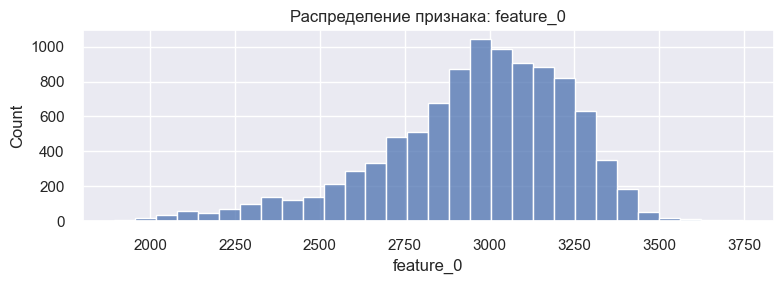

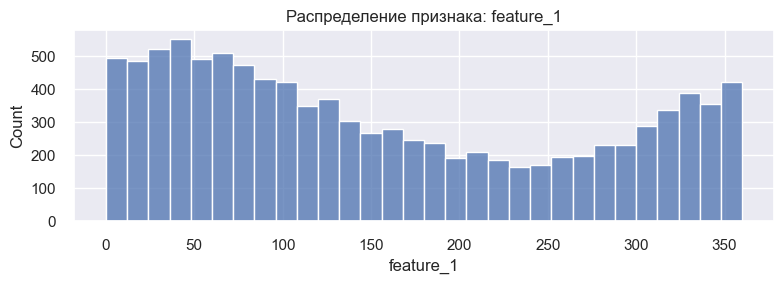

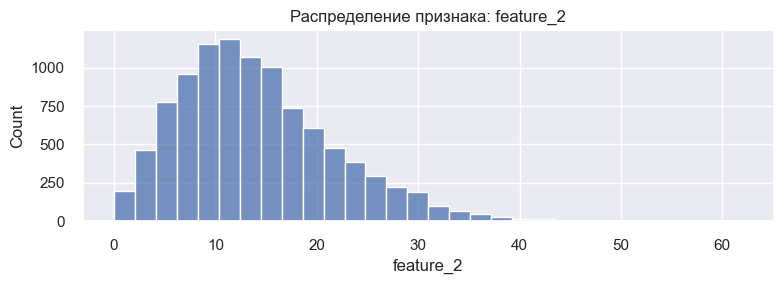

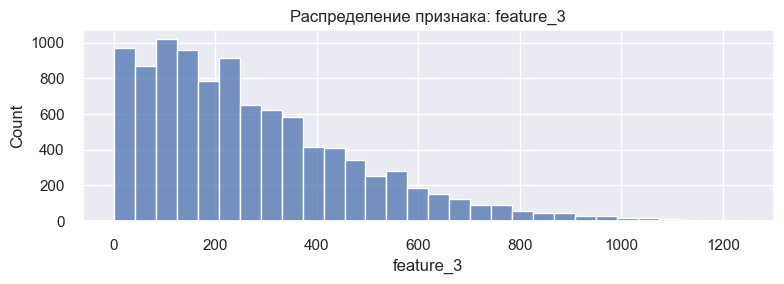

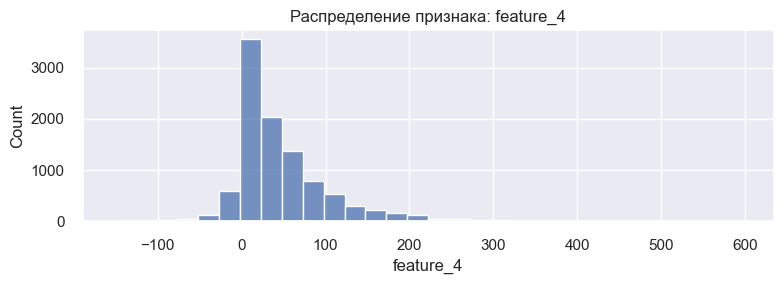

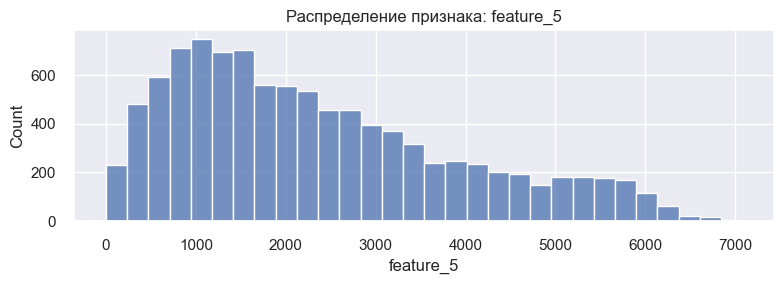

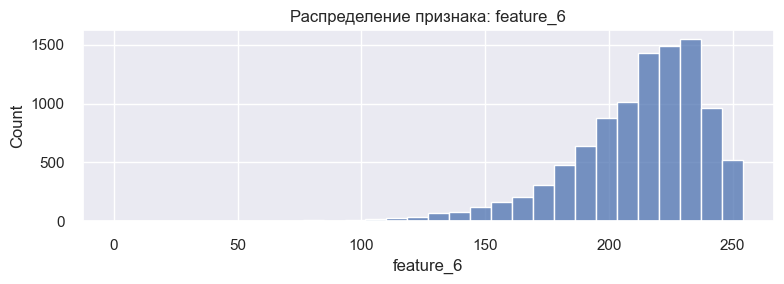

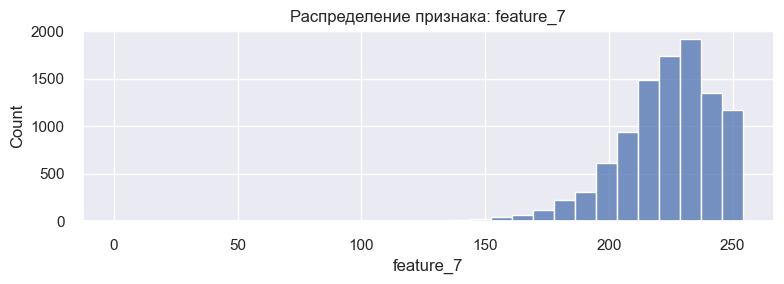

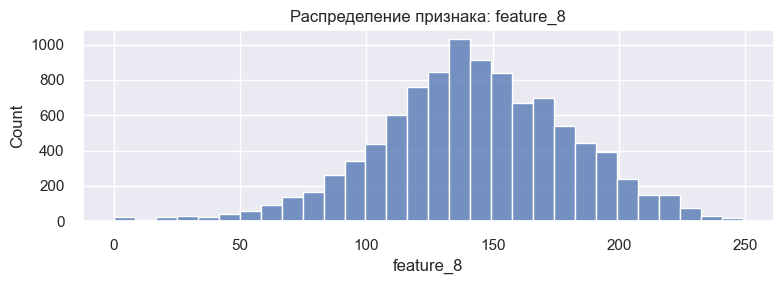

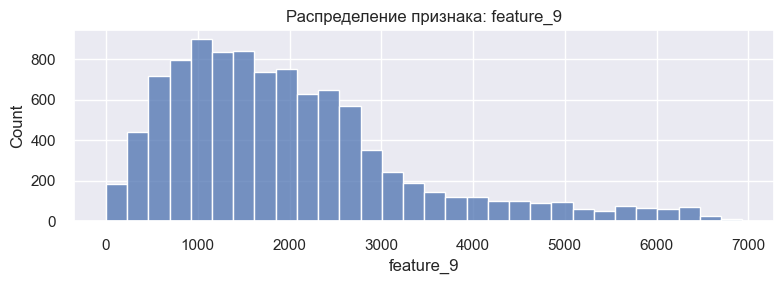

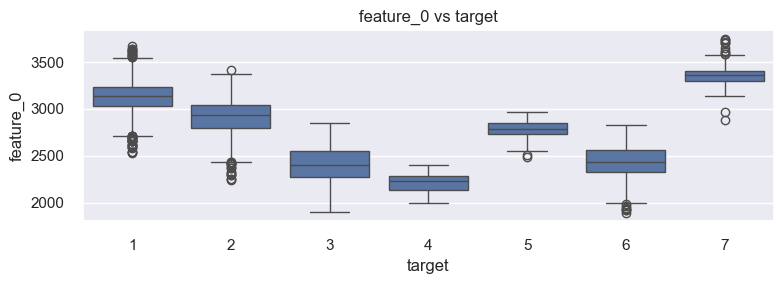

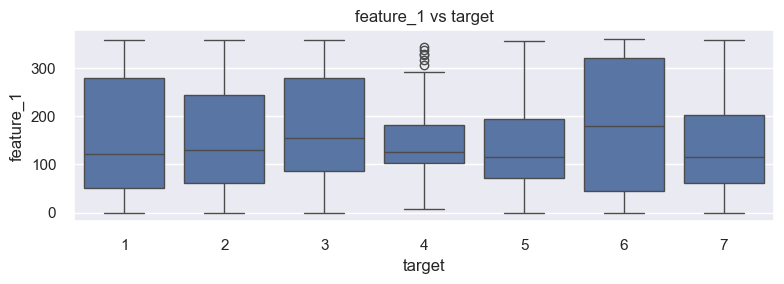

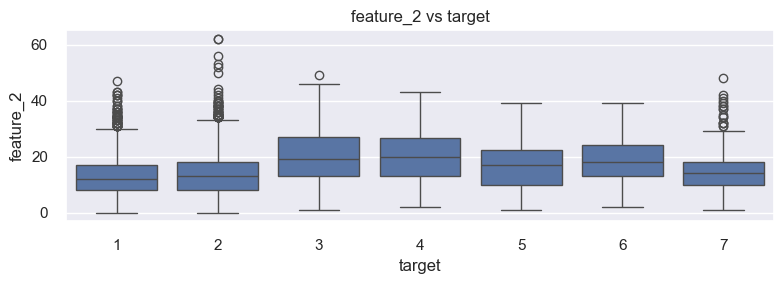

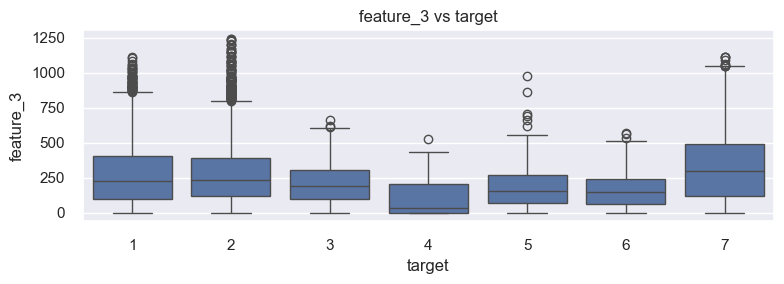

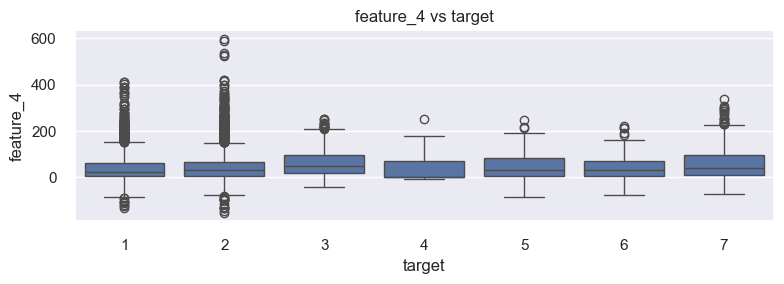

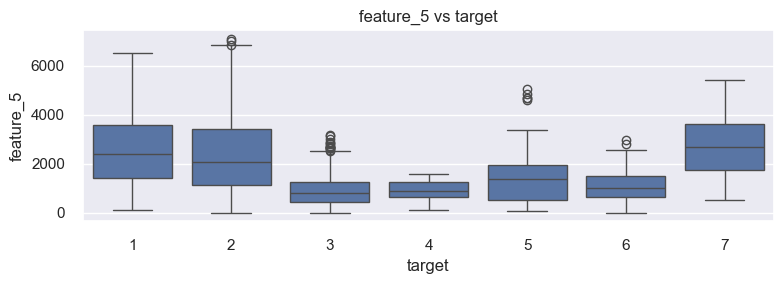

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_PATH = os.path.join("..", "datasets", "covertype", "covtype.data")

col_names = [f"feature_{i}" for i in range(54)] + ["target"]

df = pd.read_csv(DATA_PATH, header=None, names=col_names)

print("Форма датасета:", df.shape)
display(df.head())

print("\nТипы столбцов:")
print(df.dtypes)

print("\nИнформация о данных:")
df.info()

print("\nОписательная статистика числовых признаков:")
display(df.describe().T.head(20))

target_col = "target"

if target_col in df.columns:
    print("\nРаспределение классов целевой переменной:")
    display(df[target_col].value_counts().sort_index())
    print("\nДоля классов:")
    display(df[target_col].value_counts(normalize=True).sort_index())

numeric_cols = [c for c in df.columns if c != target_col]

sample_df = df.sample(n=min(len(df), 10000), random_state=42)

for col in numeric_cols[:10]:
    plt.figure(figsize=(8, 3))
    sns.histplot(sample_df[col], bins=30, kde=False)
    plt.title(f"Распределение признака: {col}")
    plt.tight_layout()
    plt.show()

if target_col in df.columns:
    for col in numeric_cols[:6]:
        plt.figure(figsize=(8, 3))
        sns.boxplot(x=target_col, y=col, data=sample_df)
        plt.title(f"{col} vs {target_col}")
        plt.tight_layout()
        plt.show()
